# WFH Burnout — 01: Exploratory Data Analysis

Explores the dataset structure, class distribution, feature distributions, correlations, and statistical significance of feature differences across burnout risk levels.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}
ORDER   = ['Low', 'Medium', 'High']

print('Libraries loaded')

Libraries loaded


In [3]:
# Load dataset and drop non-feature identifier column
CSV_PATH = 'wfh_burnout_dataset.csv'

df = pd.read_csv(CSV_PATH)
df.drop(columns=['user_id'], inplace=True)

print(df.shape)
print(df.head())

(2000, 13)
  day_type  work_hours  screen_time_hours  meetings_count  breaks_taken  \
0  Weekday        7.74               5.99               3             7   
1  Weekday        8.48               7.23               3             5   
2  Weekend        8.39               7.14               1             5   
3  Weekday       12.48              12.23               4             1   
4  Weekend        8.85               7.35               4             6   

   after_hours_work  app_switches  sleep_hours  task_completion  \
0                 0            50         7.50            74.80   
1                 0            63         7.31            86.36   
2                 0            27         6.73            89.23   
3                 1            89         6.55            64.47   
4                 0            40         8.03            98.62   

   isolation_index  fatigue_score  burnout_score burnout_risk  
0                4           3.51          17.23          Low  
1      

In [4]:
# Basic dataset inspection — data types, missing values, duplicates
df.info()
print(df.describe())
print('Missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   day_type           2000 non-null   object 
 1   work_hours         2000 non-null   float64
 2   screen_time_hours  2000 non-null   float64
 3   meetings_count     2000 non-null   int64  
 4   breaks_taken       2000 non-null   int64  
 5   after_hours_work   2000 non-null   int64  
 6   app_switches       2000 non-null   int64  
 7   sleep_hours        2000 non-null   float64
 8   task_completion    2000 non-null   float64
 9   isolation_index    2000 non-null   int64  
 10  fatigue_score      2000 non-null   float64
 11  burnout_score      2000 non-null   float64
 12  burnout_risk       2000 non-null   object 
dtypes: float64(6), int64(5), object(2)
memory usage: 203.3+ KB
        work_hours  screen_time_hours  meetings_count  breaks_taken  \
count  2000.000000        2000.000000 

In [5]:
# Define feature groups
# BEHAVIORAL: observable work-from-home behaviors used as model inputs
# LEAKAGE: fatigue_score and burnout_score are derived from the target
#          and must be excluded to prevent data leakage

BEHAVIORAL = [
    'work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken',
    'after_hours_work', 'app_switches', 'sleep_hours', 'task_completion',
    'isolation_index'
]
LEAKAGE    = ['burnout_score', 'fatigue_score']
CATEGORICAL = ['day_type']

print('Behavioral features:', BEHAVIORAL)
print('Leakage columns    :', LEAKAGE)

Behavioral features: ['work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 'after_hours_work', 'app_switches', 'sleep_hours', 'task_completion', 'isolation_index']
Leakage columns    : ['burnout_score', 'fatigue_score']


burnout_risk
Low       1019
Medium     843
High       138
Name: count, dtype: int64
burnout_risk
Low       50.9
Medium    42.2
High       6.9
Name: count, dtype: float64


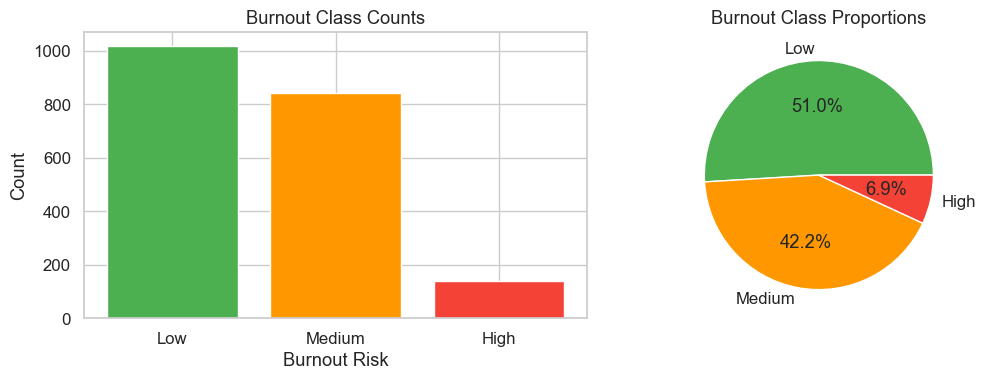

In [6]:
# Class distribution — bar chart and pie chart
counts = df['burnout_risk'].value_counts().reindex(ORDER)
pcts   = (counts / len(df) * 100).round(1)
print(counts)
print(pcts)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(ORDER, counts, color=[PALETTE[c] for c in ORDER])
axes[0].set_title('Burnout Class Counts')
axes[0].set_xlabel('Burnout Risk')
axes[0].set_ylabel('Count')
axes[1].pie(counts, labels=ORDER, colors=[PALETTE[c] for c in ORDER], autopct='%1.1f%%')
axes[1].set_title('Burnout Class Proportions')
plt.tight_layout()
plt.savefig('fig_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

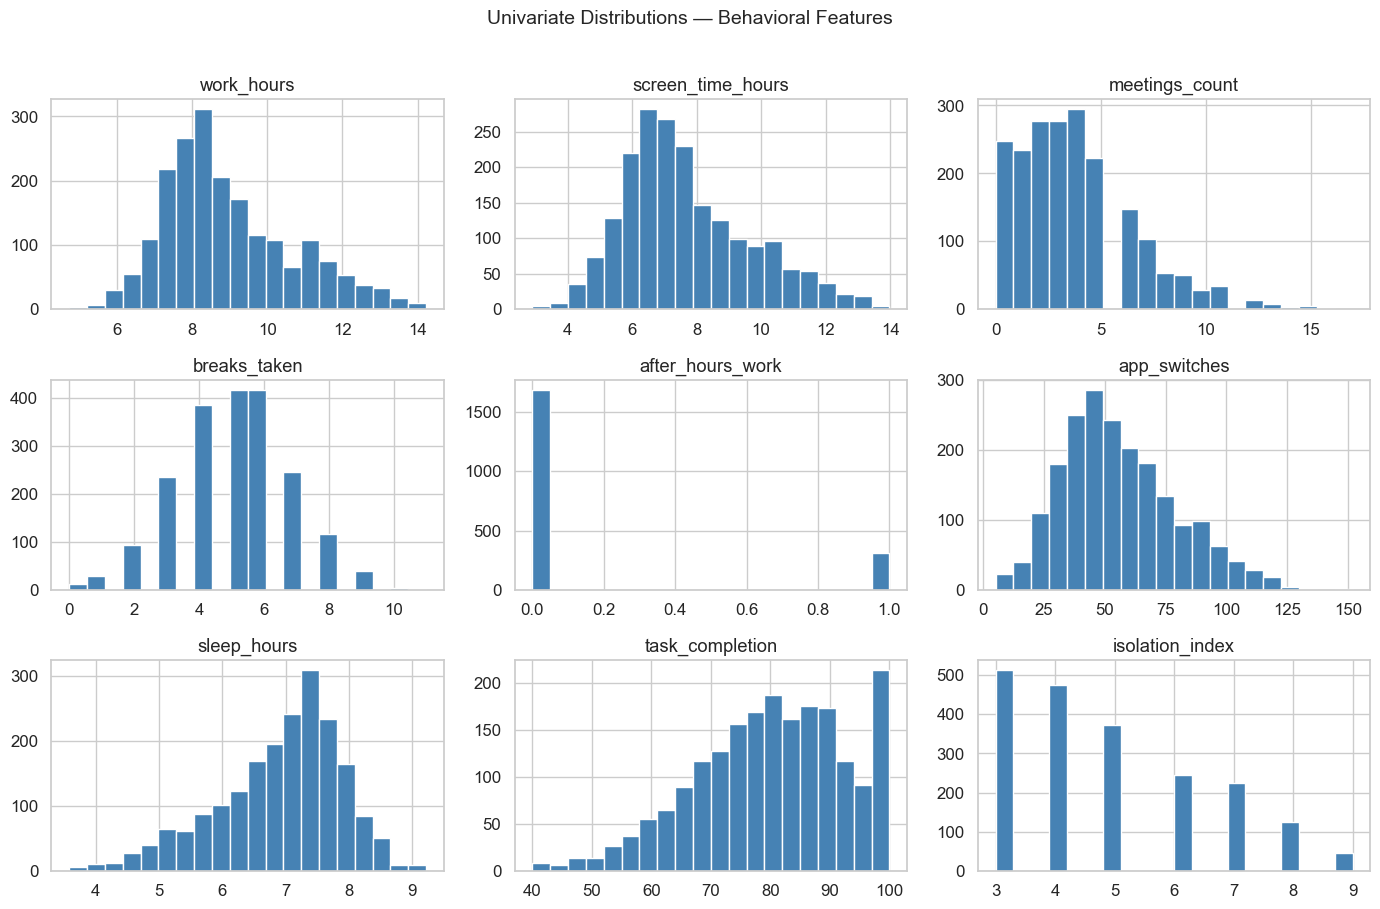

In [7]:
# Univariate histograms — distribution of each behavioral feature
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes = axes.flatten()
for i, col in enumerate(BEHAVIORAL):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
plt.suptitle('Univariate Distributions — Behavioral Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_02_univariate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

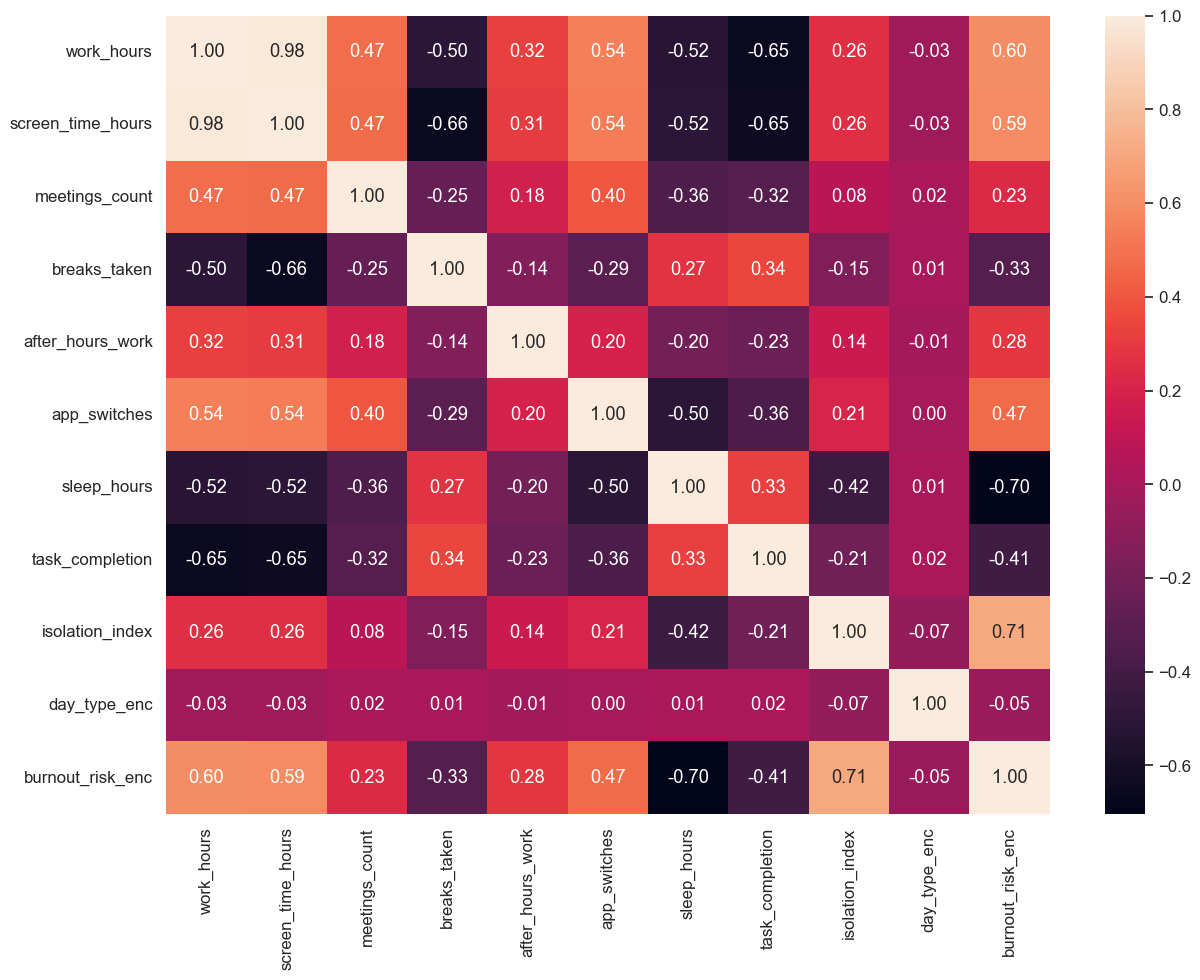

Feature correlations with burnout_risk (ranked):
isolation_index      0.709325
sleep_hours          0.703174
work_hours           0.595494
screen_time_hours    0.590114
app_switches         0.472180
task_completion      0.411988
breaks_taken         0.325784
after_hours_work     0.281596
meetings_count       0.232815
day_type_enc         0.049941


In [8]:
# Correlation heatmap — encode categoricals first, then compute and plot
df_enc = df.copy()
df_enc['day_type_enc']     = (df_enc['day_type'] == 'Weekday').astype(int)
df_enc['burnout_risk_enc'] = df_enc['burnout_risk'].map({'Low': 0, 'Medium': 1, 'High': 2})
corr_matrix = df_enc[BEHAVIORAL + ['day_type_enc', 'burnout_risk_enc']].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', ax=ax)
plt.tight_layout()
plt.savefig('fig_03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Features ranked by absolute correlation with burnout_risk
corrs = corr_matrix['burnout_risk_enc'].drop('burnout_risk_enc').abs().sort_values(ascending=False)
print('Feature correlations with burnout_risk (ranked):')
print(corrs.to_string())

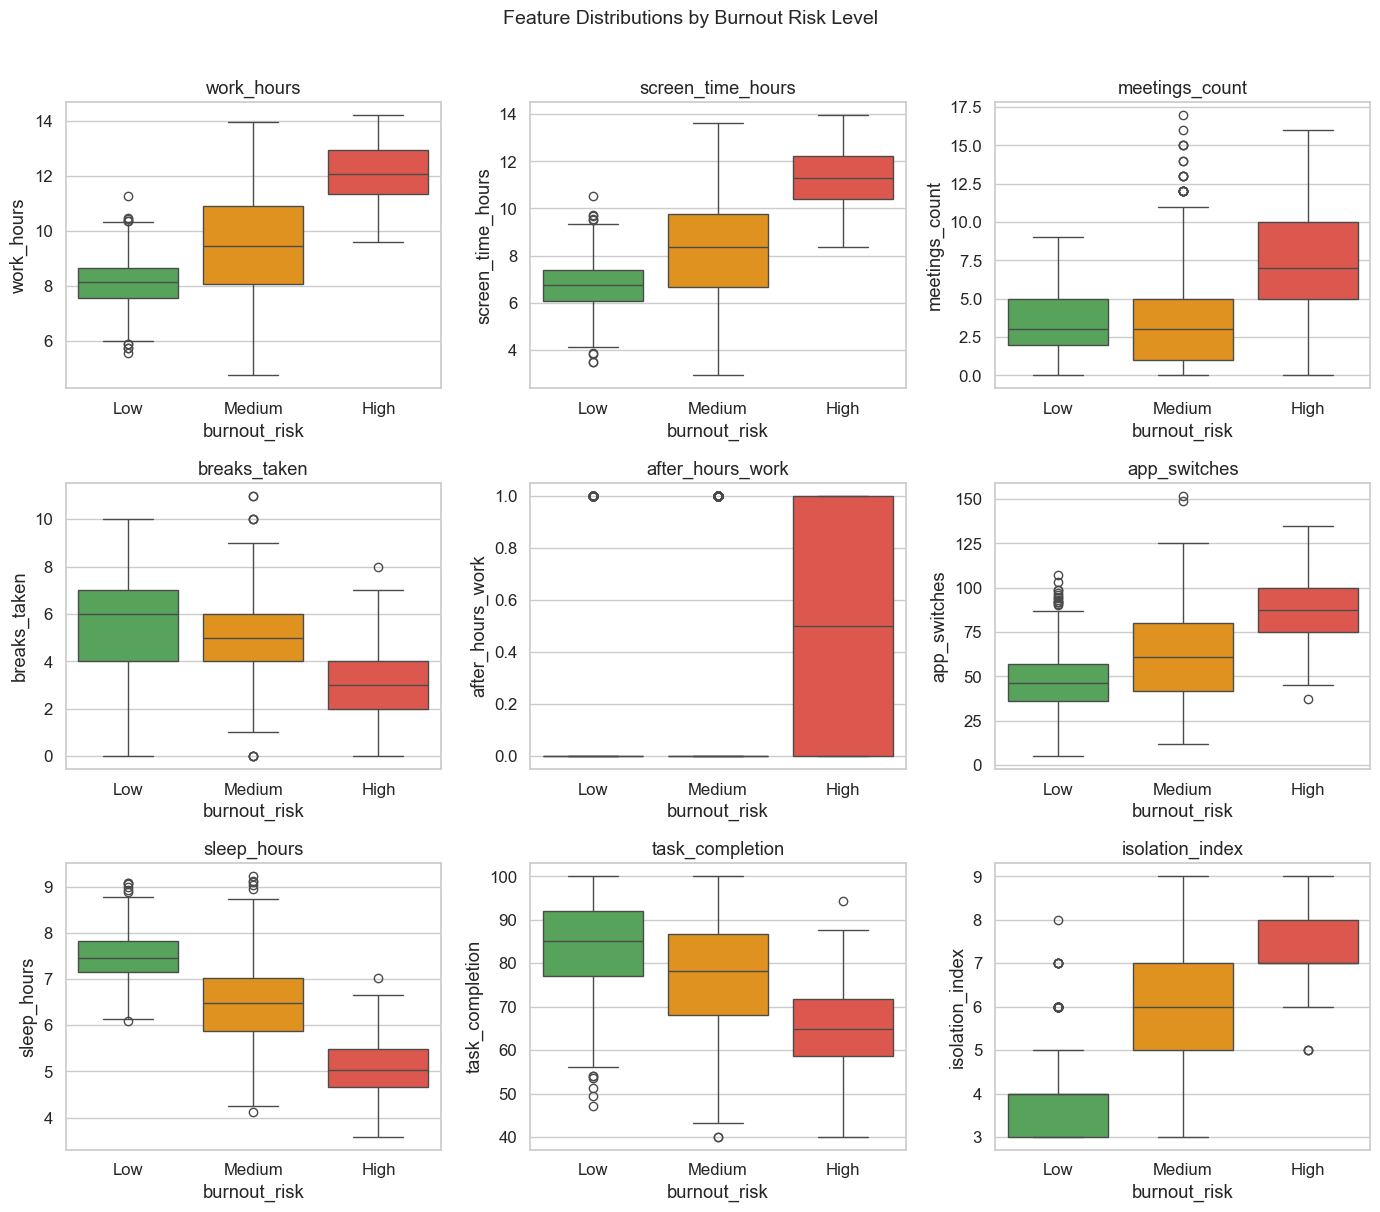

In [9]:
# Box plots by burnout class — shows distribution separation for each feature
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()
for i, col in enumerate(BEHAVIORAL):
    sns.boxplot(data=df, x='burnout_risk', y=col, order=ORDER, palette=PALETTE, ax=axes[i])
    axes[i].set_title(col)
plt.suptitle('Feature Distributions by Burnout Risk Level', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_04_boxplots_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Class mean table and High-Low delta
# Larger delta = stronger signal between extreme burnout classes
mean_table  = df.groupby('burnout_risk')[BEHAVIORAL].mean().reindex(ORDER)
delta       = (mean_table.loc['High'] - mean_table.loc['Low']).abs()
delta_sorted = delta.sort_values(ascending=False)

print('Class means per feature:')
print(mean_table.round(2))
print('\nHigh minus Low (absolute difference):')
print(delta_sorted.round(3))

Class means per feature:
              work_hours  screen_time_hours  meetings_count  breaks_taken  \
burnout_risk                                                                
Low                 8.13               6.75            3.42          5.52   
Medium              9.44               8.23            3.48          4.82   
High               12.10              11.29            7.50          3.25   

              after_hours_work  app_switches  sleep_hours  task_completion  \
burnout_risk                                                                 
Low                       0.08         46.64         7.49            84.36   
Medium                    0.19         62.25         6.47            77.48   
High                      0.50         87.28         5.07            64.54   

              isolation_index  
burnout_risk                   
Low                      3.76  
Medium                   5.85  
High                     7.18  

High minus Low (absolute difference):

In [11]:
# Kruskal-Wallis tests — non-parametric test for significant differences
# across all three burnout classes for each feature
results = []
for col in BEHAVIORAL:
    groups         = [df[df['burnout_risk'] == cls][col].values for cls in ORDER]
    h_stat, p_val  = kruskal(*groups)
    results.append({
        'Feature'              : col,
        'H-statistic'          : round(h_stat, 2),
        'p-value'              : p_val,
        'Significant (p<0.05)' : p_val < 0.05
    })

kw_df = pd.DataFrame(results).sort_values('H-statistic', ascending=False)
display(kw_df)

,Feature,H-statistic,p-value,Significant (p<0.05)
8,isolation_index,1046.92,4.610294e-228,True
6,sleep_hours,910.17,2.287160e-198,True
1,screen_time_hours,575.10,1.314020e-125,True
0,work_hours,573.47,2.974024e-125,True
5,app_switches,390.40,1.680023e-85,True
7,task_completion,317.90,9.288742e-70,True
3,breaks_taken,218.09,4.399611e-48,True
2,meetings_count,192.93,1.276909e-42,True
4,after_hours_work,179.45,1.076209e-39,True


In [12]:
# EDA summary
print('='*65)
print('EDA SUMMARY')
print('='*65)
print(f'Total records       : {len(df)}')
print(f'Behavioral features : {len(BEHAVIORAL)}')
print(f'Missing values      : {df.isnull().sum().sum()}')
print(f'Duplicate rows      : {df.duplicated().sum()}')
print()
print('Class distribution:')
for cls in ORDER:
    n = (df['burnout_risk'] == cls).sum()
    print(f'  {cls:8s}: {n:5d}  ({n/len(df)*100:.1f}%)')
print()
print('Top 3 features correlated with burnout_risk:')
for feat, val in corrs.head(3).items():
    print(f'  {feat:25s}: {val:.3f}')
print('='*65)

EDA SUMMARY
Total records       : 2000
Behavioral features : 9
Missing values      : 0
Duplicate rows      : 0

Class distribution:
  Low     :  1019  (50.9%)
  Medium  :   843  (42.1%)
  High    :   138  (6.9%)

Top 3 features correlated with burnout_risk:
  isolation_index          : 0.709
  sleep_hours              : 0.703
  work_hours               : 0.595
